# Load the dataset using pandas

In [1]:
#Importing the Libraries
import pandas as pd               # for working with tables (dataframes)
import matplotlib.pyplot as plt   # for creating charts/plots
import numpy as np                # for numerical operations and arrays
import datetime as dt
import seaborn as sns             # Advanced visualizations (boxplots, heatmaps)

In [32]:
# Uploading the File from Google drive
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/project data.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Quick preview of the data

In [33]:
df.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,1994-10-01,F,JAMSHEDPUR,17819.05,2016-02-08,143207,25.0
1,T2,C2142763,1957-04-04,M,JHAJJAR,2270.69,2016-02-08,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2016-02-08,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2016-02-08,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2016-02-08,181156,1762.5


In [36]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1041614 entries, 0 to 1041613
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1041614 non-null  object 
 1   CustomerID               1041614 non-null  object 
 2   CustomerDOB              1041614 non-null  object 
 3   CustGender               1041614 non-null  object 
 4   CustLocation             1041614 non-null  object 
 5   CustAccountBalance       1041614 non-null  float64
 6   TransactionDate          1041614 non-null  object 
 7   TransactionTime          1041614 non-null  int64  
 8   TransactionAmount (INR)  1041614 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 71.5+ MB
None


# Data Cleaning Steps

## 1. Handle Missing Values
- Identify columns with missing entries.
- Decide whether to:
  - **Remove rows** if critical fields (e.g., TransactionID, CustomerID) are missing.
  - **Impute values** for numeric fields (e.g., fill with median) or categorical fields (e.g., fill with mode).

## 2. Remove Duplicates
- Detect duplicate rows in the dataset.
- Drop duplicates to ensure each transaction is unique.

## 3. Standardize inconsistent Data Formats
- **Dates**: Convert `CustomerDOB` and `TransactionDate` into consistent `datetime` format.
- **Times**: Convert `TransactionTime` into proper `HH:MM:SS` format.
- **Categorical values**: Normalize text fields like `CustGender` (`M`/`F`) and `CustLocation` (consistent casing/spelling).
- **Numeric values**: Ensure account balances and transaction amounts are stored as floats, not strings.


In [37]:
# Fixing the CustomerDOB, TransactionDate and TransactionTime
date_iso = pd.to_datetime(df['TransactionDate'], errors='coerce')                       # Convert YYYY-MM-DD first
date_dmy = pd.to_datetime(df['TransactionDate'], format='%d/%m/%y', errors='coerce')    # Convert DD/MM/YY format next
df['TransactionDate'] = date_iso.fillna(date_dmy)                                       # Merge results

# Using the same approach for the CustomerDOB column
dob_iso = pd.to_datetime(df['CustomerDOB'], errors='coerce')
dob_dmy = pd.to_datetime(df['CustomerDOB'], format='%d/%m/%y', errors='coerce')
df['CustomerDOB'] = dob_iso.fillna(dob_dmy)

df.loc[df['CustomerDOB'] == pd.Timestamp('1800-01-01'), 'CustomerDOB'] = pd.NaT                                 # Replacing the placeholder DOB '1800-01-01' with NaT to mark it as missing
df.loc[df['CustomerDOB'] > pd.Timestamp("2016-08-02"), 'CustomerDOB'] -= pd.DateOffset(years=100)               # Fixing DOB values that fall unrealistically after 2016-08-02 by subtracting 100 years
df['TransactionTime'] = pd.to_datetime(df['TransactionTime'].astype(str).str.zfill(6), format='%H%M%S').dt.time # Turning TransactionTime into a proper time object by casting to string, padding with zeros (HHMMSS), parsing with datetime, and extracting only the time

In [38]:
print(df.dtypes)

TransactionID                      object
CustomerID                         object
CustomerDOB                datetime64[ns]
CustGender                         object
CustLocation                       object
CustAccountBalance                float64
TransactionDate            datetime64[ns]
TransactionTime                    object
TransactionAmount (INR)           float64
dtype: object


In [39]:
df.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,1994-10-01,F,JAMSHEDPUR,17819.05,2016-02-08,14:32:07,25.0
1,T2,C2142763,1957-04-04,M,JHAJJAR,2270.69,2016-02-08,14:18:58,27999.0
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-02-08,14:27:12,459.0
3,T4,C5342380,1973-09-14,F,MUMBAI,866503.21,2016-02-08,14:27:14,2060.0
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-02-08,18:11:56,1762.5


# Cleaning the inconsistent columns for duplicate CustomerIDs

In [40]:
# Checking the records of a particular CustomerID that has inconsistent CustomerDOBs and CustGenders
df[df['CustomerID'] == 'C1113684']

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
463068,T466366,C1113684,1982-01-16,M,UDHAMPUR,9.85,2016-08-21,18:54:03,477.0
526255,T530017,C1113684,1987-11-04,F,BANGALORE,17797.66,2016-08-23,21:10:04,348.0
564610,T568646,C1113684,1989-02-14,M,CHENNAI,37657.39,2016-08-27,07:50:26,34980.0
653490,T658168,C1113684,1989-07-06,M,SECUNDERABAD,1345.18,2016-08-28,19:57:28,40.0
673076,T677867,C1113684,1994-08-18,M,KANGRA,51054.96,2016-08-28,13:11:08,30.0
759457,T764794,C1113684,NaT,M,NEW DELHI,214567.77,2016-01-09,11:43:14,1998.0


### Flow of Demographic Cleaning Logic

**CustomerDOB**
1. Group records by CustomerID and DOB.
2. Count how many times each DOB appears per CustomerID.
3. Sort by:
   - Count (descending: most frequent first).
   - DOB (ascending: earliest first if tie).
4. Keep the first DOB per CustomerID.
5. Map the cleaned DOB back to the main DataFrame.

**CustGender**
1. Group records by CustomerID and Gender.
2. Count how many times each Gender appears per CustomerID.
3. Record the earliest TransactionDate for each Gender.
4. Sort by:
   - Count (descending: most frequent first).
   - TransactionDate (ascending: earliest first if tie).
5. Keep the first Gender per CustomerID.
6. Map the cleaned Gender back to the main DataFrame.

**Result**
- Each CustomerID now has a consistent DOB and Gender.
- Conflicts are resolved systematically:
  - DOB: most frequent, else earliest.
  - Gender: most frequent, else earliest recorded.
- TransactionID remains the unique identifier, so every transaction stays distinct.

In [41]:
# Cleaning CustomerDOB column: keep the most frequent DOB per customer (earliest if tie)
dob_clean = (
    df.groupby(['CustomerID','CustomerDOB']).size().reset_index(name='count')
      .sort_values(['CustomerID','count','CustomerDOB'], ascending=[True, False, True])
      .drop_duplicates('CustomerID')
      .set_index('CustomerID')['CustomerDOB']
)
df['CustomerDOB_Clean'] = df['CustomerID'].map(dob_clean)

# Cleaning CustGender column: keep the most frequent gender per customer (earliest transaction if tie)
gender_clean = (
    df.groupby(['CustomerID','CustGender'])['TransactionDate'].min().reset_index()
      .assign(count=df.groupby(['CustomerID','CustGender']).size().values)
      .sort_values(['CustomerID','count','TransactionDate'], ascending=[True, False, True])
      .drop_duplicates('CustomerID')
      .set_index('CustomerID')['CustGender']
)
df['CustGender_Clean'] = df['CustomerID'].map(gender_clean)

In [42]:
# Checking the records of the same CustomerID to confirm the inconsistent CustomerDOBs and CustGenders have been resolved
df[df['CustomerID'] == 'C1113684']

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),CustomerDOB_Clean,CustGender_Clean
463068,T466366,C1113684,1982-01-16,M,UDHAMPUR,9.85,2016-08-21,18:54:03,477.0,1982-01-16,M
526255,T530017,C1113684,1987-11-04,F,BANGALORE,17797.66,2016-08-23,21:10:04,348.0,1982-01-16,M
564610,T568646,C1113684,1989-02-14,M,CHENNAI,37657.39,2016-08-27,07:50:26,34980.0,1982-01-16,M
653490,T658168,C1113684,1989-07-06,M,SECUNDERABAD,1345.18,2016-08-28,19:57:28,40.0,1982-01-16,M
673076,T677867,C1113684,1994-08-18,M,KANGRA,51054.96,2016-08-28,13:11:08,30.0,1982-01-16,M
759457,T764794,C1113684,NaT,M,NEW DELHI,214567.77,2016-01-09,11:43:14,1998.0,1982-01-16,M


In [43]:
# Comparing the raw vs cleaned values for DOB and Gender to get the count of changes made
dob_changes = (df['CustomerDOB'] != df['CustomerDOB_Clean']).sum()                                      # Flag where DOB changed
gender_changes = (df['CustGender'] != df['CustGender_Clean']).sum()                                     # Flag where Gender changed
print("Number of records with DOB changed:", dob_changes)
print("Number of records with Gender changed:", gender_changes)

# Checking how many unique CustomerIDs were affected
dob_changed_ids = df.loc[df['CustomerDOB'] != df['CustomerDOB_Clean'], 'CustomerID'].nunique()
gender_changed_ids = df.loc[df['CustGender'] != df['CustGender_Clean'], 'CustomerID'].nunique()
print("Unique CustomerIDs with DOB changed:", dob_changed_ids)
print("Unique CustomerIDs with Gender changed:", gender_changed_ids)

Number of records with DOB changed: 201316
Number of records with Gender changed: 59798
Unique CustomerIDs with DOB changed: 180924
Unique CustomerIDs with Gender changed: 59341


In [44]:
# Dropping the inconsistent columns and renaming the cleaned ones.
df = df.drop(columns=['CustomerDOB','CustGender'])
df = df.rename(columns={'CustomerDOB_Clean':'CustomerDOB','CustGender_Clean':'CustGender'})

In [45]:
# Checking the records of the same CustomerID to confirm the inconsistent CustomerDOBs and CustGenders have been resolved
df[df['CustomerID'] == 'C1113684']

,TransactionID,CustomerID,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),CustomerDOB,CustGender
463068,T466366,C1113684,UDHAMPUR,9.85,2016-08-21,18:54:03,477.0,1982-01-16,M
526255,T530017,C1113684,BANGALORE,17797.66,2016-08-23,21:10:04,348.0,1982-01-16,M
564610,T568646,C1113684,CHENNAI,37657.39,2016-08-27,07:50:26,34980.0,1982-01-16,M
653490,T658168,C1113684,SECUNDERABAD,1345.18,2016-08-28,19:57:28,40.0,1982-01-16,M
673076,T677867,C1113684,KANGRA,51054.96,2016-08-28,13:11:08,30.0,1982-01-16,M
759457,T764794,C1113684,NEW DELHI,214567.77,2016-01-09,11:43:14,1998.0,1982-01-16,M


# Keep the gender as Male and Female only

In [46]:
# To work on the gender column, first count by gender
df['CustGender'].value_counts()

,count
CustGender,
M,764582
F,277031
T,1


In [47]:
# Dropping the single outlier record to avoid skewing gender spending analysis
df = df[df['CustGender'].isin(['M','F'])].copy()

# Mapping the shorthand M/F to full labels Male/Female
gender_map = {'M': 'Male', 'F': 'Female'}
df['CustGender'] = df['CustGender'].map(gender_map)

# Quick check of gender counts after cleaning
print(df['CustGender'].value_counts())

CustGender
Male      764582
Female    277031
Name: count, dtype: int64


In [48]:
df.head()

,TransactionID,CustomerID,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),CustomerDOB,CustGender
0,T1,C5841053,JAMSHEDPUR,17819.05,2016-02-08,14:32:07,25.0,1994-10-01,Female
1,T2,C2142763,JHAJJAR,2270.69,2016-02-08,14:18:58,27999.0,1957-04-04,Male
2,T3,C4417068,MUMBAI,17874.44,2016-02-08,14:27:12,459.0,1996-11-26,Female
3,T4,C5342380,MUMBAI,866503.21,2016-02-08,14:27:14,2060.0,1973-09-14,Female
4,T5,C9031234,NAVI MUMBAI,6714.43,2016-02-08,18:11:56,1762.5,1988-03-24,Female


In [52]:
# Checking the records of the same CustomerID to confirm the inconsistent CustomerDOBs and CustGenders have been resolved
df[df['CustomerID'] == 'C1376215']

,TransactionID,CustomerID,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),CustomerDOB,CustGender,Age
16,T17,C1376215,MUMBAI,77495.15,2016-01-08,12:47:27,1423.11,NaT,Male,NaN


# Task 2: Exploratory Data Analysis (EDA)

### Description: Perform an exploratory analysis on a given dataset to identify patterns, trends, and summary statistics.

---


1. **Summary Statistics**
   - Calculate mean, median, mode, and standard deviation for numerical features.

2. **Data Visualization**
   - Plot histograms to understand distributions.
   - Use boxplots to detect outliers.
   - Create scatter plots to explore relationships between variables.

3. **Correlation Analysis**
   - Find correlations between numerical features.
   - Use correlation matrices and heatmaps for visualization.

---

### Tools: Python, pandas, matplotlib, seaborn


1. **Summary Statistics:** Calculate minimum, maximum, mean, median, mode, and standard deviation for numerical features.

In [49]:
# Customer Account Balance

print("Customer Account Balance Summary")

print("Minimum:", df['CustAccountBalance'].min())
print("Maximum:", df['CustAccountBalance'].max())
print("Mean:", df['CustAccountBalance'].mean())
print("Median:", df['CustAccountBalance'].median())
print("Mode:", df['CustAccountBalance'].mode()[0])
print("Standard Deviation:", df['CustAccountBalance'].std())

Customer Account Balance Summary
Minimum: 0.0
Maximum: 115035495.1
Mean: 114998.66763713583
Median: 16768.52
Mode: 0.0
Standard Deviation: 846761.344390976


In [50]:
# Transaction Amount (INR)

print("Transaction Amount Summary")
print("Minimum:", df['TransactionAmount (INR)'].min())
print("Maximum:", df['TransactionAmount (INR)'].max())
print("Mean:", df['TransactionAmount (INR)'].mean())
print("Median:", df['TransactionAmount (INR)'].median())
print("Mode:", df['TransactionAmount (INR)'].mode()[0])
print("Standard Deviation:", df['TransactionAmount (INR)'].std())

Transaction Amount Summary
Minimum: 0.0
Maximum: 1560034.99
Mean: 1566.06638139117
Median: 457.5
Mode: 100.0
Standard Deviation: 6561.397516962491


In [69]:
# Customer Age

# Calculating Age (using TransactionDate as reference) firstly
df['Age'] = (
    df['TransactionDate'].dt.year - df['CustomerDOB'].dt.year
    - (
        (df['TransactionDate'].dt.month < df['CustomerDOB'].dt.month) |
        (
            (df['TransactionDate'].dt.month == df['CustomerDOB'].dt.month) &
            (df['TransactionDate'].dt.day   <  df['CustomerDOB'].dt.day)
        )
    ).astype(int)
)

print("Customer Age Summary")
print("Minimum:", df['Age'].min())
print("Maximum:", df['Age'].max())
print("Mean:", df['Age'].mean())
print("Median:", df['Age'].median())
print("Mode:", df['Age'].mode()[0])
print("Standard Deviation:", df['Age'].std())

Customer Age Summary
Minimum: 0.0
Maximum: 98.0
Mean: 31.98348173429301
Median: 30.0
Mode: 26.0
Standard Deviation: 9.32279448912655


# Task 3: Basic Data Visualization
### Visualize data distributions using line charts, histograms, boxplots and scatter plots.

In [56]:
# Extracting year, month, and month name safely
df['TransactionYear'] = df['TransactionDate'].dt.year.astype('Int64')   # nullable integer
df['TransactionMonth'] = df['TransactionDate'].dt.month.astype('Int64') # nullable integer
df['TransactionMonthName'] = df['TransactionDate'].dt.month_name()

# Quick check
print(df[['TransactionDate','TransactionYear','TransactionMonth','TransactionMonthName']].head())
print(df[['TransactionYear','TransactionMonth']].dtypes)


  TransactionDate  TransactionYear  TransactionMonth TransactionMonthName
0      2016-02-08             2016                 2             February
1      2016-02-08             2016                 2             February
2      2016-02-08             2016                 2             February
3      2016-02-08             2016                 2             February
4      2016-02-08             2016                 2             February
TransactionYear     Int64
TransactionMonth    Int64
dtype: object


In [58]:
# Defining Age Groups
bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['<25','25-34','35-44','45-54','55-64','65+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)     # Cutting ages into bins
df['AgeGroup'] = df['AgeGroup'].cat.add_categories(['Unknown'])               # Adding 'Unknown' category for missing ages
df.loc[df['Age'].isna(), 'AgeGroup'] = 'Unknown'

df.head()

,TransactionID,CustomerID,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),CustomerDOB,CustGender,Age,TransactionYear,TransactionMonth,TransactionMonthName,AgeGroup
0,T1,C5841053,JAMSHEDPUR,17819.05,2016-02-08,14:32:07,25.0,1994-10-01,Female,21.0,2016,2,February,<25
1,T2,C2142763,JHAJJAR,2270.69,2016-02-08,14:18:58,27999.0,1957-04-04,Male,58.0,2016,2,February,55-64
2,T3,C4417068,MUMBAI,17874.44,2016-02-08,14:27:12,459.0,1996-11-26,Female,19.0,2016,2,February,<25
3,T4,C5342380,MUMBAI,866503.21,2016-02-08,14:27:14,2060.0,1973-09-14,Female,42.0,2016,2,February,35-44
4,T5,C9031234,NAVI MUMBAI,6714.43,2016-02-08,18:11:56,1762.5,1988-03-24,Female,27.0,2016,2,February,25-34


# **Bar Charts, Histogram, Line chart, and Box plot for analysis involving age**

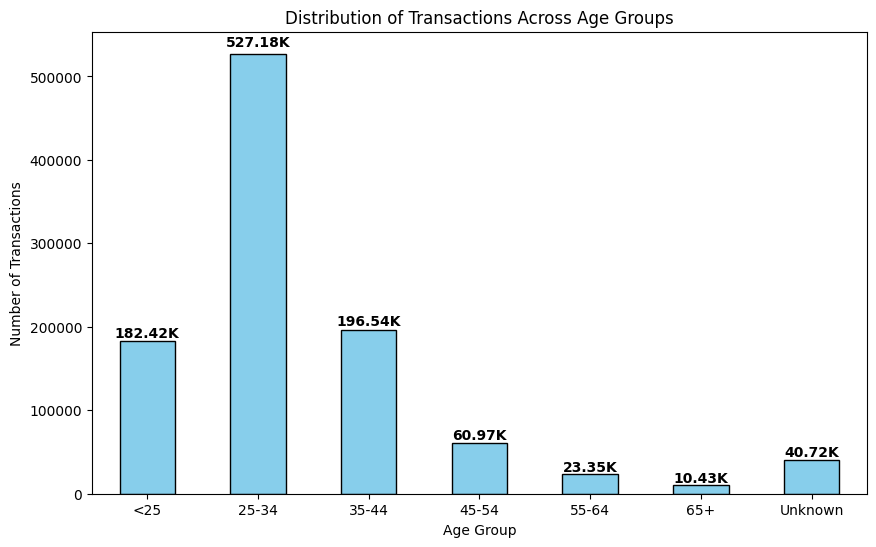

In [62]:
# Bar chart of Transactions by Age Group
counts = df['AgeGroup'].value_counts().sort_index()                                 # Get counts per age group
ax = counts.plot(kind='bar', color='skyblue', edgecolor='black', figsize=(10,6))    # Plot chart

# Add labels on top of bars
for i, val in enumerate(counts):
    if val >= 1_000_000:
        label = f"{val/1_000_000:.2f}M"   # millions with 2 decimals
    elif val >= 1_000:
        label = f"{val/1000:.2f}K"        # thousands with 2 decimals
    else:
        label = f"{val:.2f}"

    ax.text(i, val + (val*0.01), label, ha='center', va='bottom', fontsize=10, fontweight='bold')

# Titles and labels
plt.title("Distribution of Transactions Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.show()

/tmp/ipykernel_22797/292483642.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_amount_by_age = df.groupby('AgeGroup')['TransactionAmount (INR)'].mean()                      # Calculate average transaction amount per age group


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

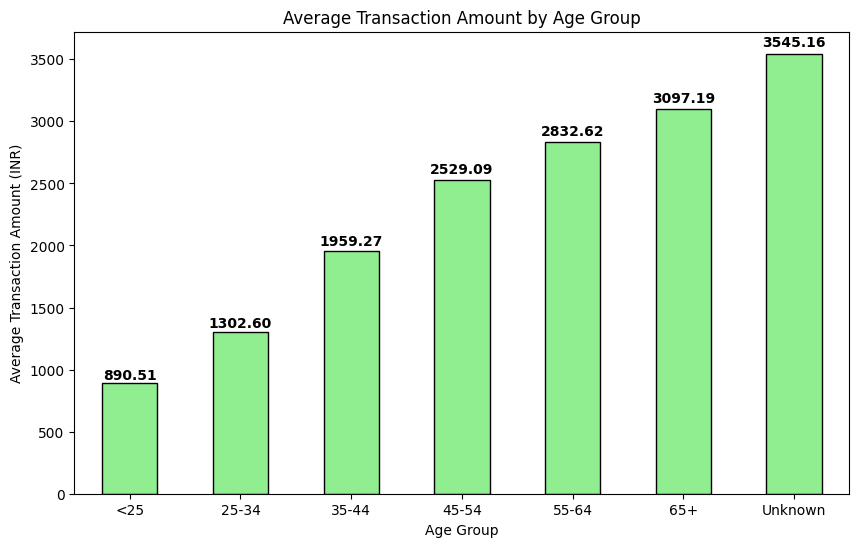

In [116]:
# Bar Chart: Average Transaction Amount by Age Group
avg_amount_by_age = df.groupby('AgeGroup')['TransactionAmount (INR)'].mean()                      # Calculate average transaction amount per age group
ax = avg_amount_by_age.plot(kind='bar', color='lightgreen', edgecolor='black', figsize=(10,6))    # Plot bar chart

# Add labels on top of bars (2 decimal places)
for i, val in enumerate(avg_amount_by_age):
    label = f"{val:.2f}"   # format with 2 decimals
    ax.text(i, val + (val*0.01), label, ha='center', va='bottom', fontsize=10, fontweight='bold')

# Titles and labels
plt.title("Average Transaction Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Transaction Amount (INR)")
plt.xticks(rotation=0)
plt.savefig("Bar chart of Average Transaction Amount by Age Group", dpi=300, bbox_inches='tight')       # Saving as PNG in high resolution
files.download("Bar chart of Average Transaction Amount by Age Group.png")                              # Downloading to local computer
plt.show()

/tmp/ipykernel_22797/3138391452.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_agegroup = df.groupby(['TransactionMonth','AgeGroup'])['TransactionAmount (INR)'].mean().unstack()


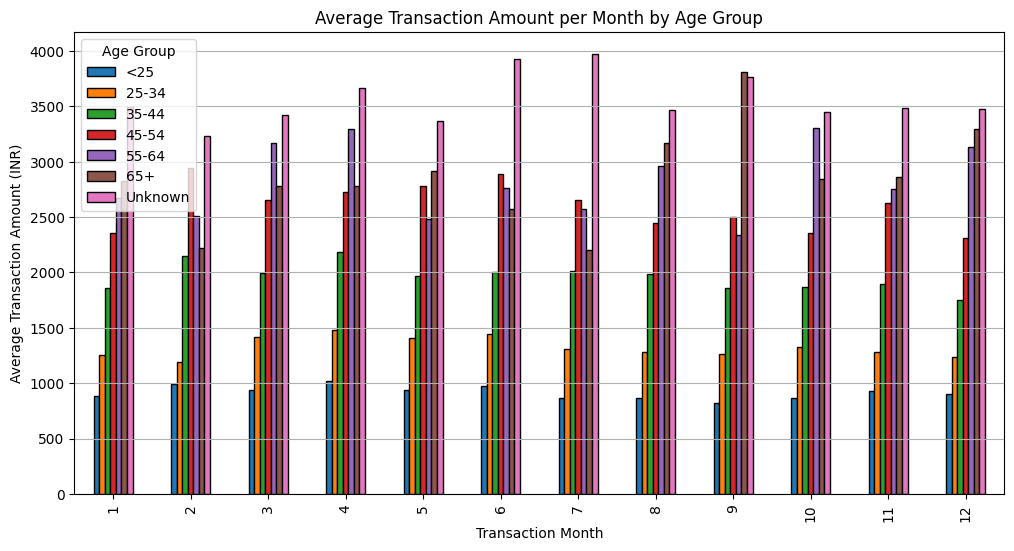

In [125]:
# Average Transaction Amount per Month by Age Group
monthly_agegroup = df.groupby(['TransactionMonth','AgeGroup'])['TransactionAmount (INR)'].mean().unstack()

ax = monthly_agegroup.plot(kind='bar', figsize=(12,6), edgecolor='black')
plt.title("Average Transaction Amount per Month by Age Group")
plt.xlabel("Transaction Month")
plt.ylabel("Average Transaction Amount (INR)")
plt.legend(title="Age Group")
plt.grid(axis='y')
plt.show()

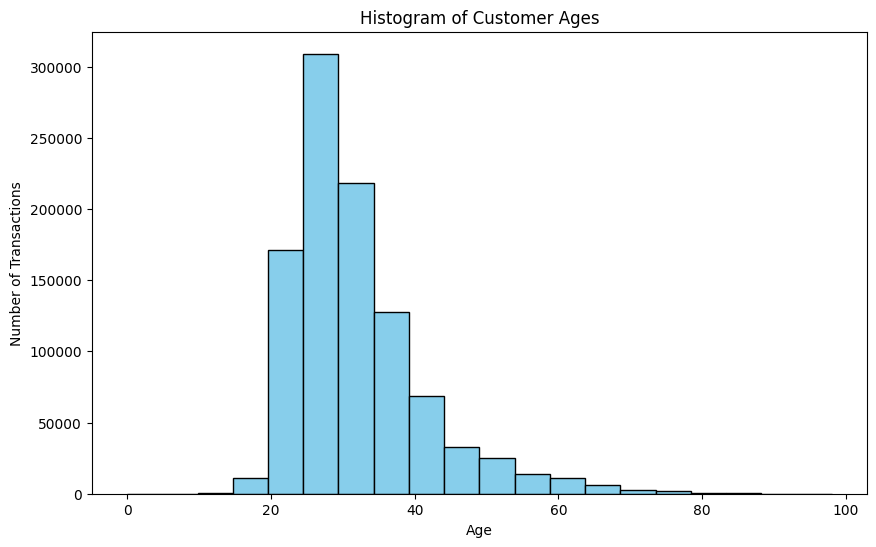

In [65]:
# Histogram of Customer Ages using the raw ages, not the age groups
ages = df['Age'].dropna() # Drop missing ages to avoid NaN issues

# Plotting histogram
plt.figure(figsize=(10,6))
plt.hist(ages, bins=20, color='skyblue', edgecolor='black')

# Titles and labels
plt.title("Histogram of Customer Ages")
plt.xlabel("Age")
plt.ylabel("Number of Transactions")

plt.show()

/tmp/ipykernel_22797/157096909.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agegroup_avg = df.groupby('AgeGroup')['TransactionAmount (INR)'].mean()      # Calculate average transaction amount per Age Group


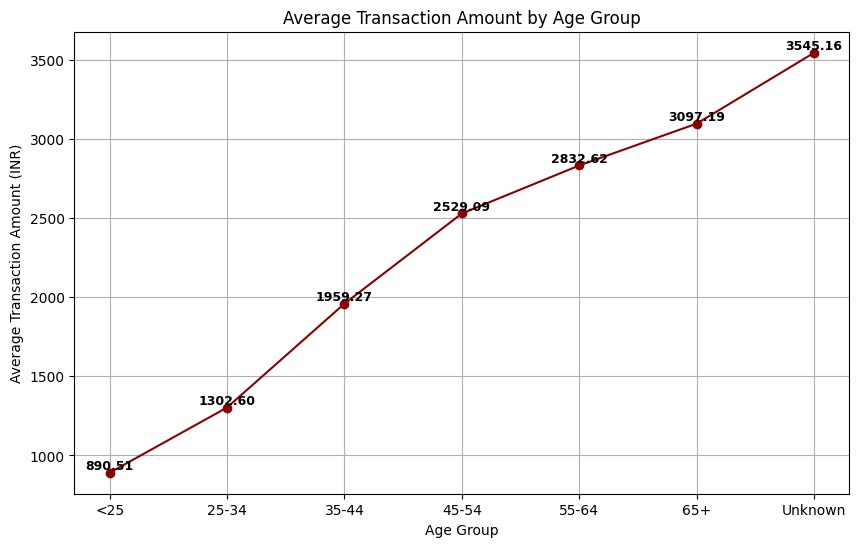

In [104]:
# Line chart: Average transaction amount by Age Group
agegroup_avg = df.groupby('AgeGroup')['TransactionAmount (INR)'].mean()      # Calculate average transaction amount per Age Group

ax = agegroup_avg.plot(kind='line', marker='o', color='darkred', figsize=(10,6))     # Plot line chart

# Adding labels on each point (2 decimal places)
for i, val in enumerate(agegroup_avg):
    label = f"{val:.2f}"
    ax.text(i, val, label, ha='center', va='bottom', fontsize=9, fontweight='bold')

# Titles and labels
plt.title("Average Transaction Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Transaction Amount (INR)")
plt.grid(True)
plt.show()

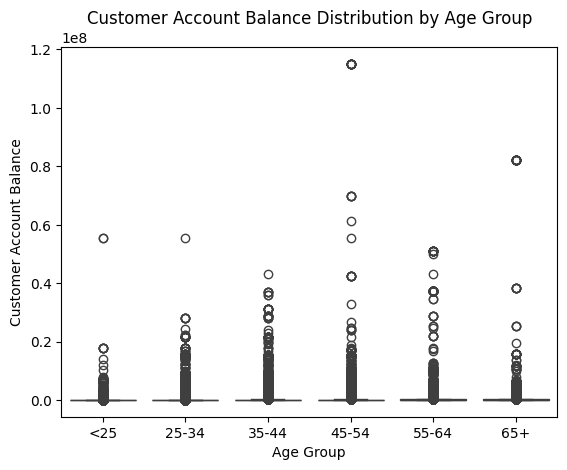

In [74]:
# Boxplot: Customer Account Balance by Age Group
sns.boxplot(x='AgeGroup', y='CustAccountBalance', data=df, order=labels)

plt.title("Customer Account Balance Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Customer Account Balance")
plt.show()

## Comments on Customer Account Balance Distribution by Age Group

The boxplot illustrates how account balances vary across different age brackets:

- **Most balances are clustered near zero** across all groups, indicating that the majority of customers maintain modest balances.
- **Outliers dominate the scale**, particularly in the **45–54 age group**, where a few individuals hold extremely high balances. These skew the distribution and highlight wealth concentration.
- **Middle‑aged groups (35–54)** show the widest spread, reflecting diverse financial situations. Some customers accumulating significant wealth while others remain at modest levels.
- **Younger groups (<25 and 25–34)** are more consistent, with balances tightly clustered at the lower end, suggesting limited financial accumulation early in life.
- **Older groups (55+)** appear more stable, with fewer extreme outliers, indicating steadier but modest balances in later years.

### Key Insight
The distribution follows a **long‑tailed pattern**: while most customers hold small balances, a small subset, especially in midlife, drives the extremes. This highlights both the concentration of wealth and the variability in financial behavior across age groups.

# **Scatterplots**

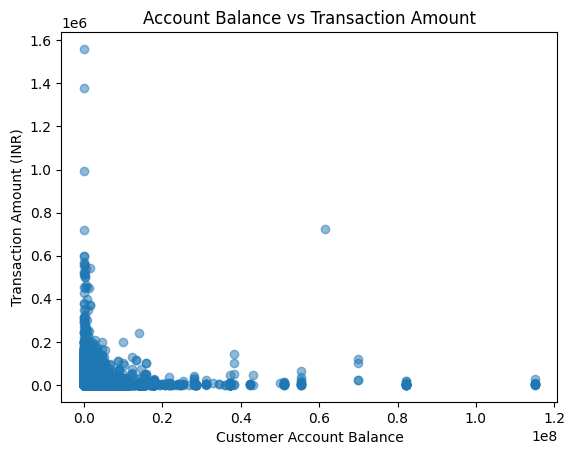

In [75]:
# Scatterplot: Account Balance vs Transaction Amount
plt.scatter(df['CustAccountBalance'], df['TransactionAmount (INR)'], alpha=0.5)
plt.title("Account Balance vs Transaction Amount")
plt.xlabel("Customer Account Balance")
plt.ylabel("Transaction Amount (INR)")
plt.show()

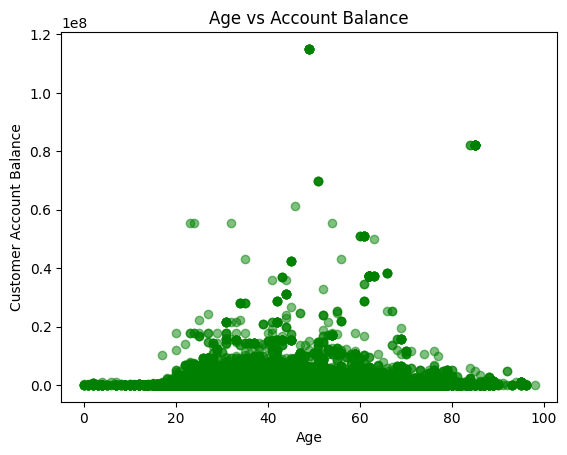

In [76]:
# Scatterplot: Age vs Account Balance
plt.scatter(df['Age'], df['CustAccountBalance'], alpha=0.5, color='green')
plt.title("Age vs Account Balance")
plt.xlabel("Age")
plt.ylabel("Customer Account Balance")
plt.show()

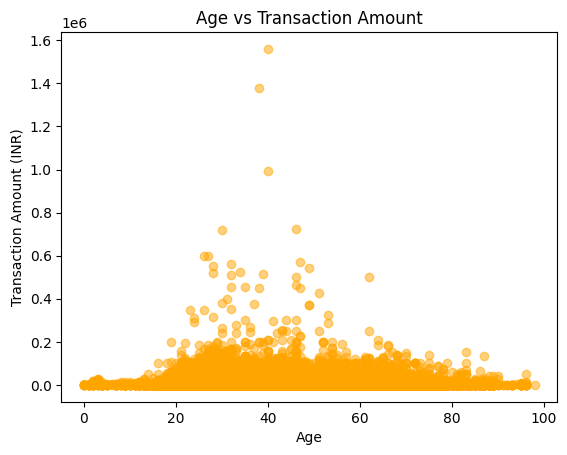

In [77]:
# Scatterplot: Age vs Transaction Amount
plt.scatter(df['Age'], df['TransactionAmount (INR)'], alpha=0.5, color='orange')
plt.title("Age vs Transaction Amount")
plt.xlabel("Age")
plt.ylabel("Transaction Amount (INR)")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

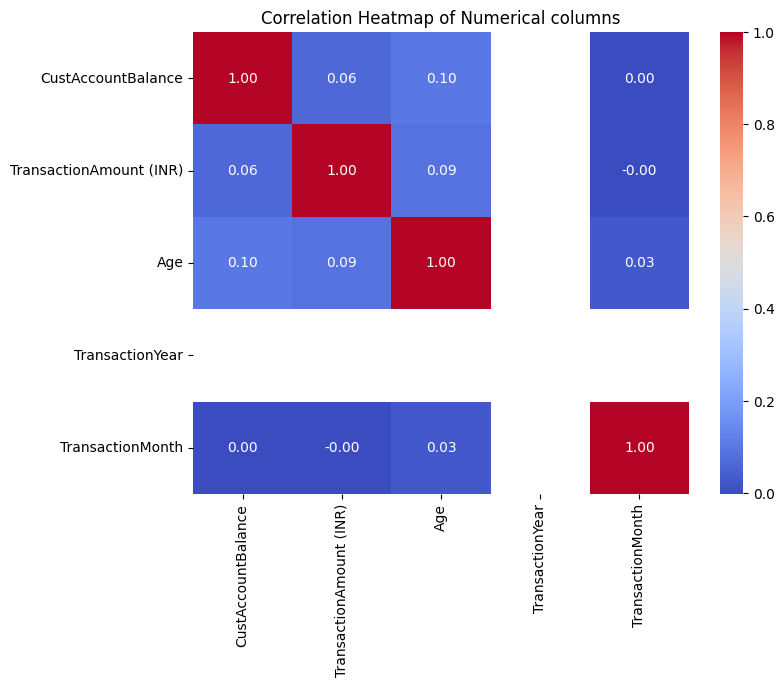

In [114]:
# Correlation heatmap of numerical columns
num_cols = ['CustAccountBalance', 'TransactionAmount (INR)', 'Age', 'TransactionYear', 'TransactionMonth']
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical columns")
plt.savefig("Correlation Heatmap of Numerical columns.png", dpi=300, bbox_inches='tight')   # Saving as PNG in high resolution
files.download("Correlation Heatmap of Numerical columns.png")                              # Downloading to local computer
plt.show()
plt.close()

## Correlation Analysis of Numerical columns

The correlation heatmap shows how numerical variables in the dataset move together:

- **Most relationships are weak**, meaning variables don’t strongly influence each other.
- **Age and Account Balance** show a mild positive link: older customers tend to hold slightly higher balances.
- **Transaction Amount** has little correlation with other variables, suggesting spending size is independent of age or balance.
- **Transaction Year and Month** are largely unrelated to balances or amounts, indicating timing doesn’t drive financial behavior.

### Top 3 Correlations
1. **Age vs CustAccountBalance**: Mild positive correlation (older customers hold higher balances).  
2. **TransactionYear vs Age**: Weak positive correlation (age naturally increases with later transaction years).  
3. **CustAccountBalance vs TransactionAmount (INR)**: Very weak correlation, showing balances don’t strongly predict spending amounts.

### Key Takeaway
The dataset highlights a **long‑tailed financial pattern**: while age has some influence on balances, transaction amounts and timing remain largely independent. This suggests customer spending behavior is varied and not easily predicted by demographic or account data alone.

# **Line Charts and Histogram for analysis involving TransactionDate (Month)**

/tmp/ipykernel_22797/3003439819.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = df.groupby('TransactionMonthName')['TransactionAmount (INR)'].mean()      # Calculate average transaction amount per month


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

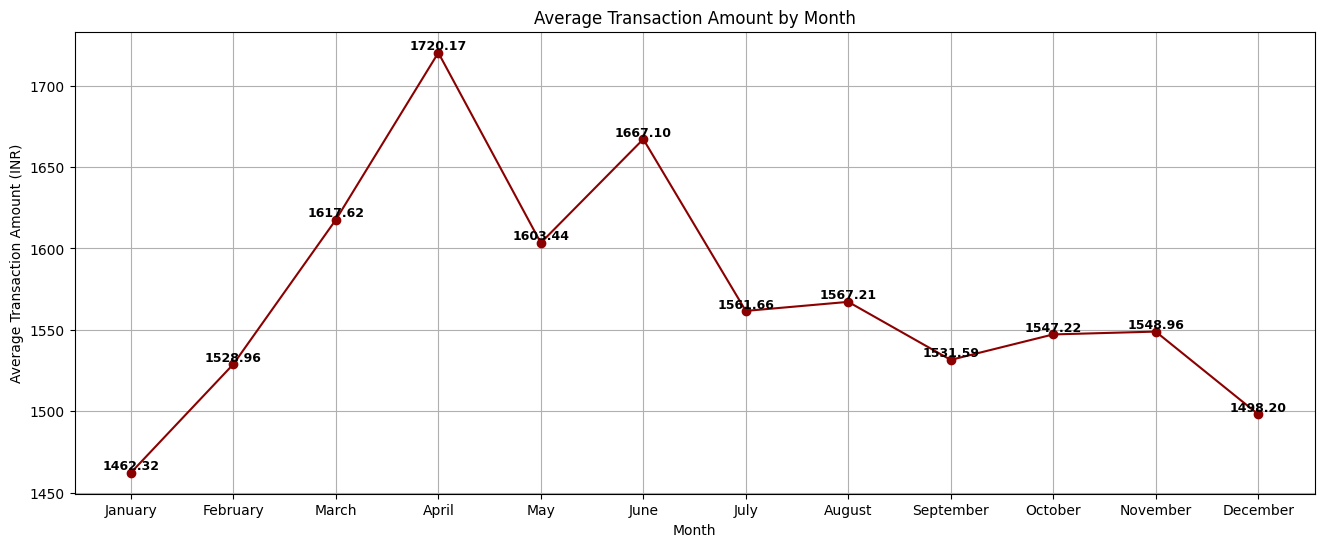

In [152]:
# Line chart: Average transaction amount by month
monthly_avg = df.groupby('TransactionMonthName')['TransactionAmount (INR)'].mean()      # Calculate average transaction amount per month

ax = monthly_avg.plot(kind='line', marker='o', color='darkred', figsize=(16,6))     # Plot line chart

# Adding labels on each point (2 decimal places)
for i, val in enumerate(monthly_avg):
    label = f"{val:.2f}"
    ax.text(i, val, label, ha='center', va='bottom', fontsize=9, fontweight='bold')

# Titles and labels
plt.title("Average Transaction Amount by Month")
plt.xlabel("Month")
plt.ylabel("Average Transaction Amount (INR)")
plt.grid(True)
plt.xticks(range(len(monthly_avg)), monthly_avg.index)  # ensuring the months show correctly
plt.savefig("Line chart of Average Transaction Amount by Month", dpi=300, bbox_inches='tight')       # Saving as PNG in high resolution
files.download("Line chart of Average Transaction Amount by Month.png")                              # Downloading to local computer
plt.show()

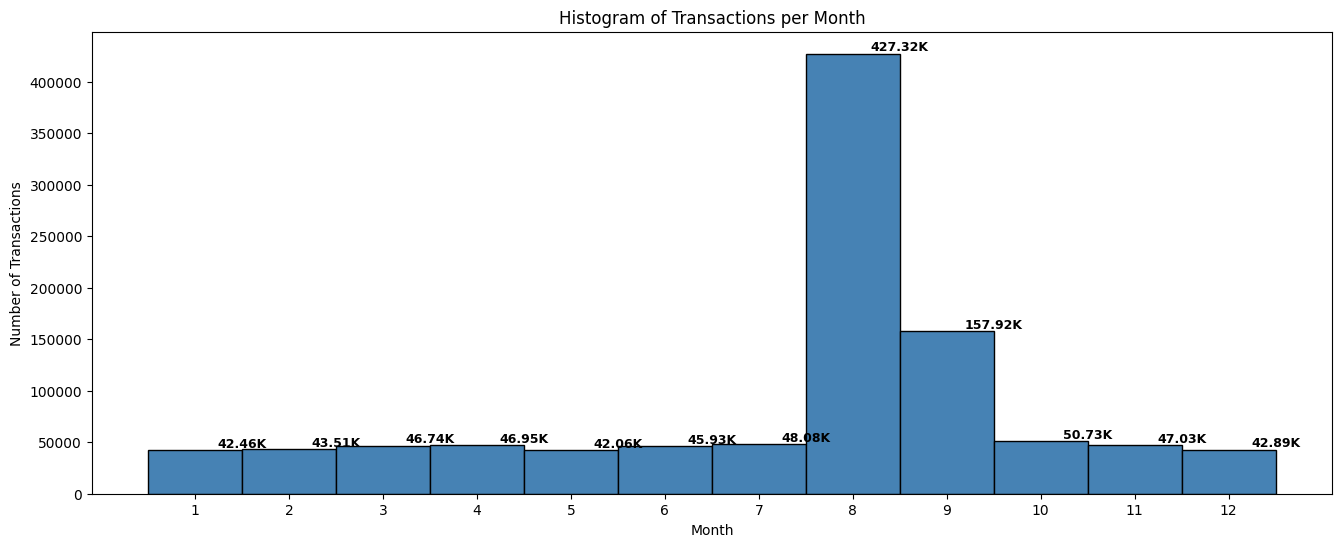

In [154]:
# Histogram: Number of Transactions per Month

months = df['TransactionMonth'].dropna().astype(int) # Drop missing months if any

# Plotting histogram (bins for months 1–12)
plt.figure(figsize=(16,6))
counts, bins, patches = plt.hist(months, bins=range(1,14), color='steelblue', edgecolor='black', align='left')

# Adding labels on top of bars with K/M formatting
for count, left, right in zip(counts, bins[:-1], bins[1:]):
    if count > 0:
        if count >= 1_000_000:
            label = f"{count/1_000_000:.2f}M"
        elif count >= 1_000:
            label = f"{count/1000:.2f}K"
        else:
            label = f"{count:.2f}"

        plt.text((left+right)/2, count, label,
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

# Titles and labels
plt.title("Histogram of Transactions per Month")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(range(1,13))  # show months 1–12
plt.show()

/tmp/ipykernel_22797/2338662617.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_total = df.groupby('TransactionMonthName')['TransactionAmount (INR)'].sum()


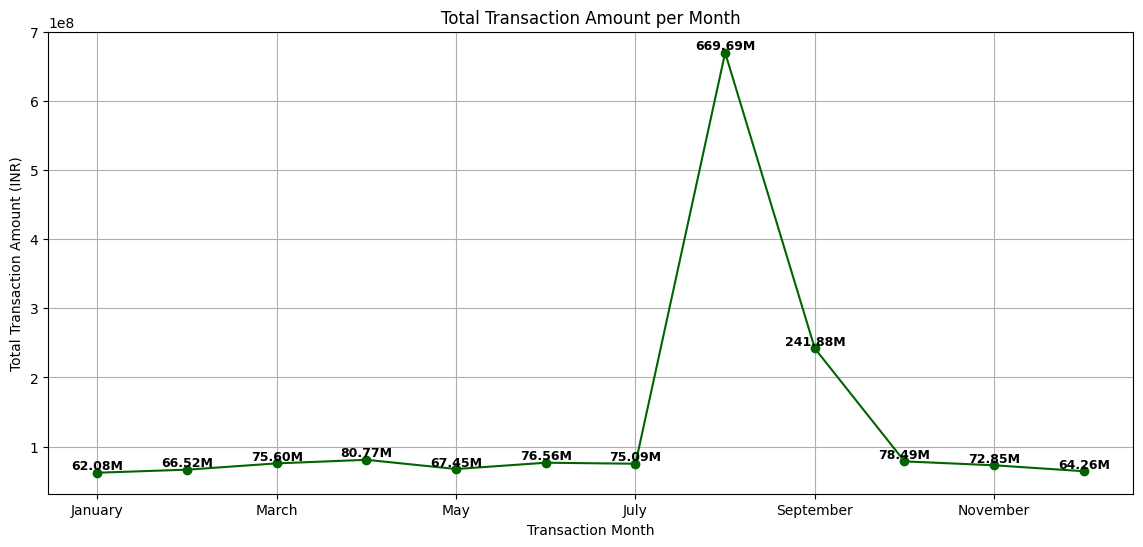

In [153]:
# Line chart: Total Transaction Amount per Month
monthly_total = df.groupby('TransactionMonthName')['TransactionAmount (INR)'].sum()

ax = monthly_total.plot(kind='line', marker='o', color='darkgreen', figsize=(14,6))

# Add labels with K/M formatting
for i, val in enumerate(monthly_total):
    if val >= 1_000_000:
        label = f"{val/1_000_000:.2f}M"
    elif val >= 1_000:
        label = f"{val/1_000:.2f}K"
    else:
        label = str(val)
    ax.text(i, val, label, ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title("Total Transaction Amount per Month")
plt.xlabel("Transaction Month")
plt.ylabel("Total Transaction Amount (INR)")
plt.grid(True)
plt.show()

/tmp/ipykernel_22797/1138432436.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_balance_avg = df.groupby('TransactionMonthName')['CustAccountBalance'].mean()


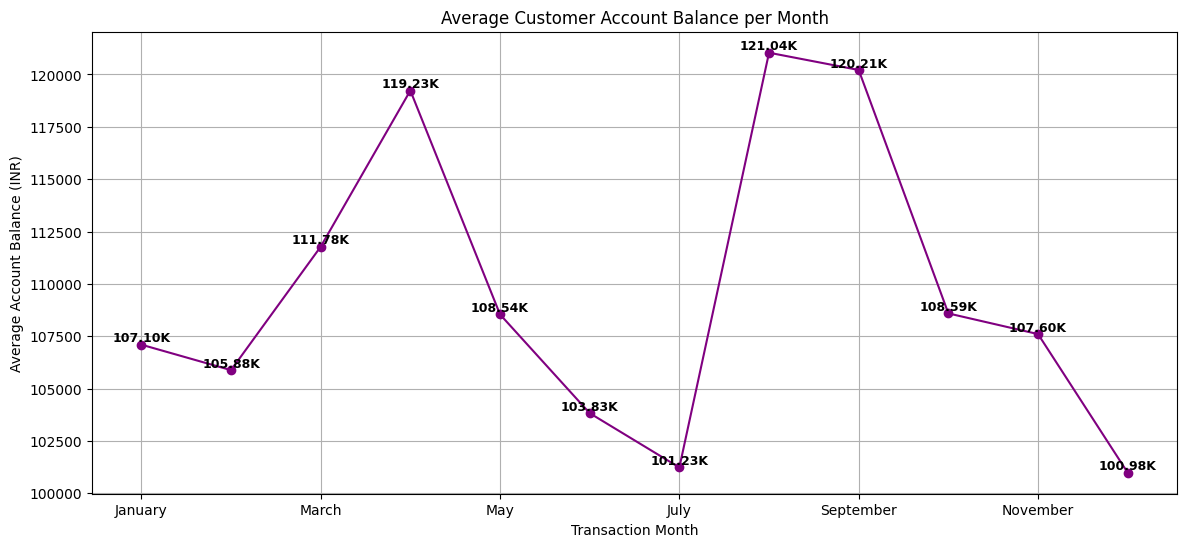

In [155]:
# Average Customer Account Balance per Month
monthly_balance_avg = df.groupby('TransactionMonthName')['CustAccountBalance'].mean()

ax = monthly_balance_avg.plot(kind='line', marker='o', color='purple', figsize=(14,6))

# Add labels with K/M formatting
for i, val in enumerate(monthly_balance_avg):
    if val >= 1_000_000:
        label = f"{val/1_000_000:.2f}M"
    elif val >= 1_000:
        label = f"{val/1_000:.2f}K"
    else:
        label = f"{val:.2f}"
    ax.text(i, val, label, ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title("Average Customer Account Balance per Month")
plt.xlabel("Transaction Month")
plt.ylabel("Average Account Balance (INR)")
plt.grid(True)
plt.show()

/tmp/ipykernel_22797/1564719581.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_location_count = df_top.groupby(['TransactionMonthName','CustLocation'])['TransactionID'].count().unstack().fillna(0).sort_index()


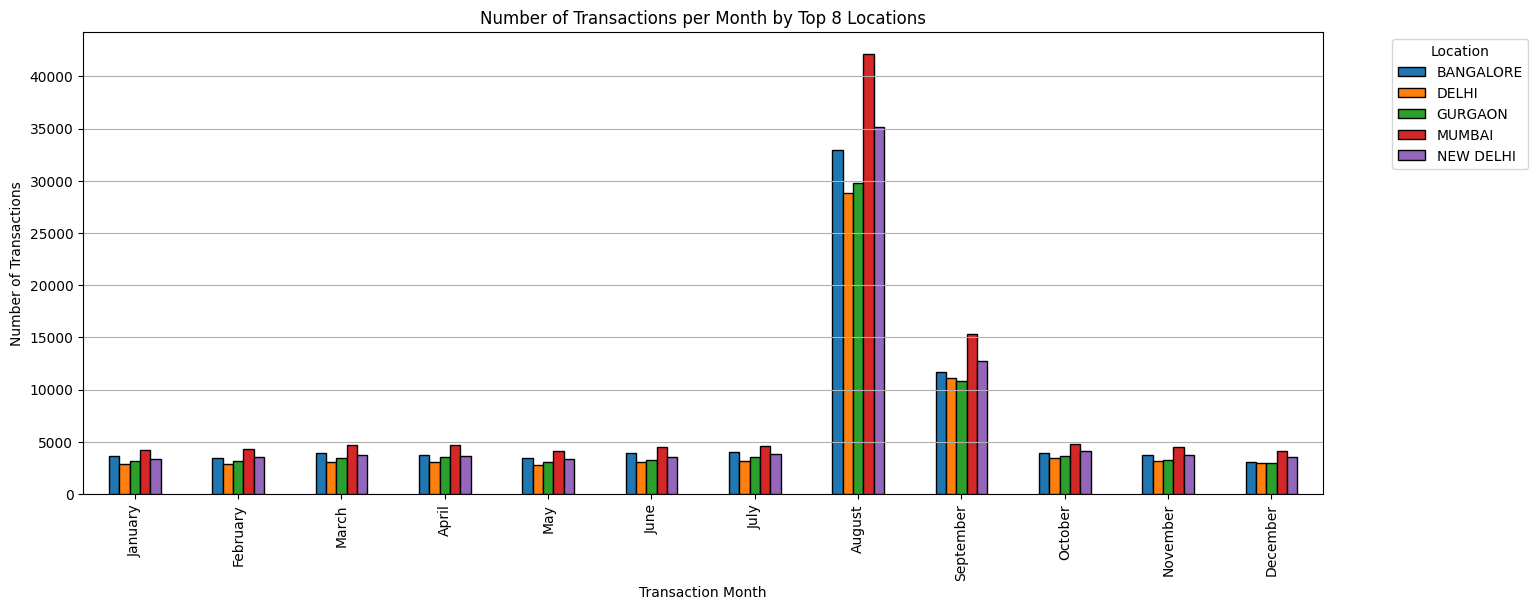

In [156]:
top_locations = df['CustLocation'].value_counts().head().index
df_top = df[df['CustLocation'].isin(top_locations)]
monthly_location_count = df_top.groupby(['TransactionMonthName','CustLocation'])['TransactionID'].count().unstack().fillna(0).sort_index()

ax = monthly_location_count.plot(kind='bar', figsize=(16,6), edgecolor='black')
plt.title("Number of Transactions per Month by Top 8 Locations")
plt.xlabel("Transaction Month")
plt.ylabel("Number of Transactions")
plt.legend(title="Location", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y')
plt.show()

/tmp/ipykernel_22797/818350464.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_gender_avg = df.groupby(['TransactionMonthName','CustGender'])['TransactionAmount (INR)'].mean().unstack()


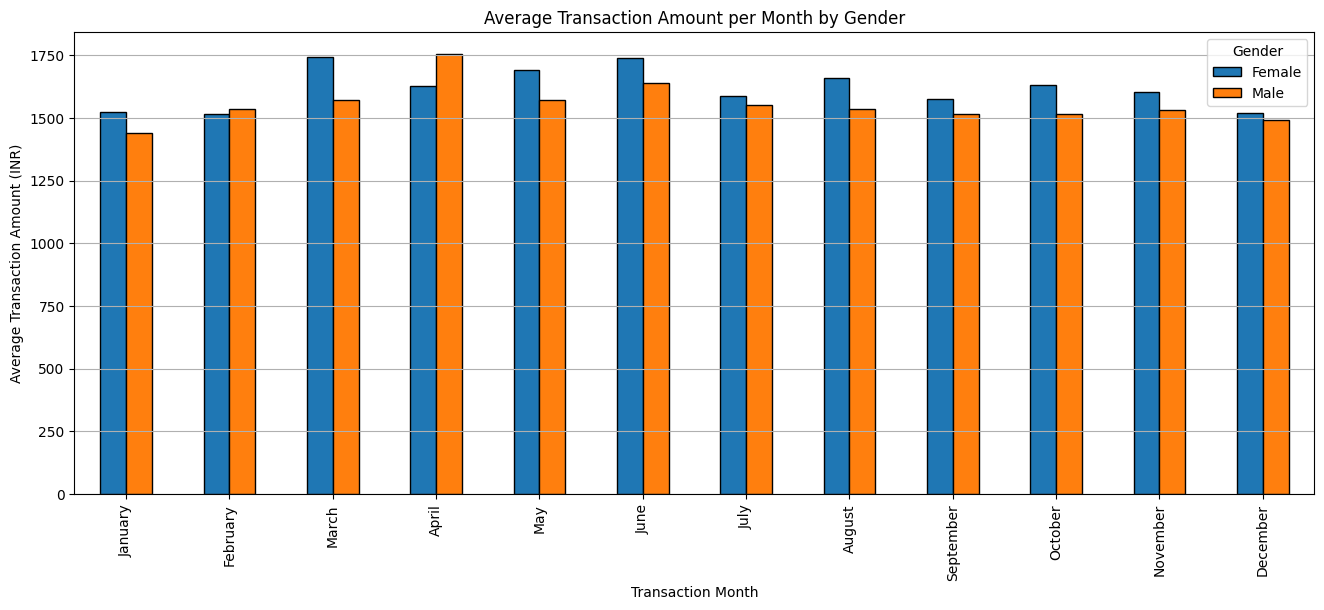

In [160]:
# Average Transaction Amount per Month by Gender
monthly_gender_avg = df.groupby(['TransactionMonthName','CustGender'])['TransactionAmount (INR)'].mean().unstack()

ax = monthly_gender_avg.plot(kind='bar', figsize=(16,6), edgecolor='black')
plt.title("Average Transaction Amount per Month by Gender")
plt.xlabel("Transaction Month")
plt.ylabel("Average Transaction Amount (INR)")
plt.legend(title="Gender")
plt.grid(axis='y')
plt.show()

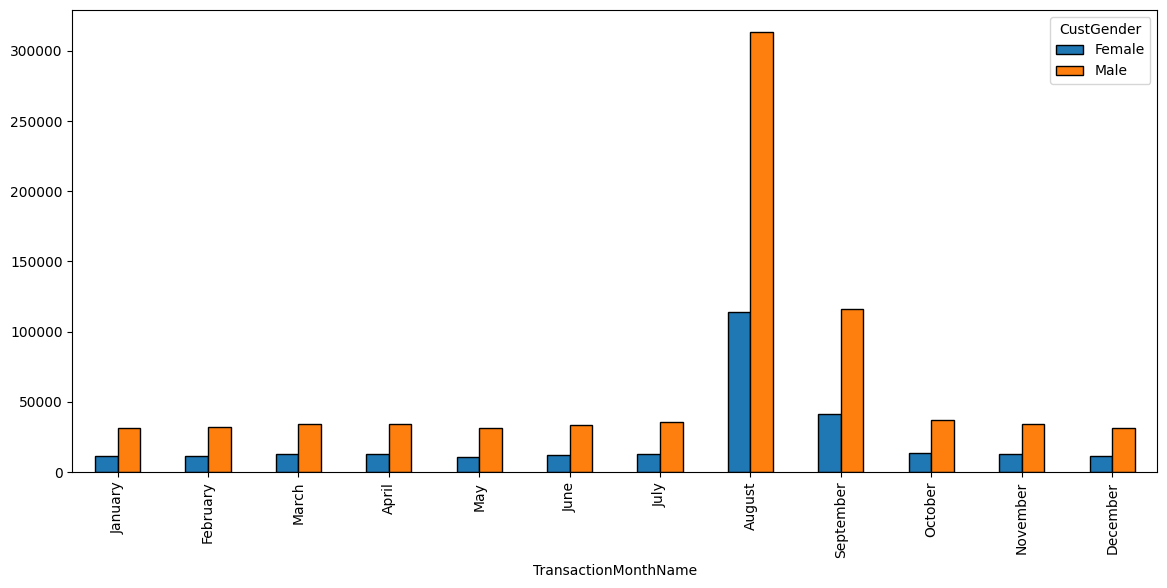

In [159]:
# Transactions per Month by Gender
monthly_gender = df.groupby(['TransactionMonthName','CustGender'])['TransactionID'].count().unstack()

ax = monthly_gender.plot(kind='bar', figsize=(14,6), edgecolor='black')
plt.title("Number of Transactions per Month by Gender")
plt.xlabel("Transaction Month")
plt.ylabel("Number of Transactions")
plt.legend(title="Gender")
plt.grid(axis='y')
plt.show()

# Export and download

In [108]:
# Export cleaned DataFrame to CSV
df.to_csv("cleaned_project_data_May.csv", index=False, na_rep="unknown")

In [109]:
from google.colab import files
files.download("cleaned_project_data_May.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>